# ПЗ 1 Обработка изображений cv2

## 1. Разложение по цвету

Импортируем библиотеки

In [2]:
import cv2
import matplotlib.pyplot as plt

Загружаем изображение

In [3]:
img = cv2.imread('images/371412.png')

Перевод в Ч/Б

In [17]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Разложение на BGR каналы

In [18]:
blue_channel, green_channel, red_channel = cv2.split(img)

Визуализация

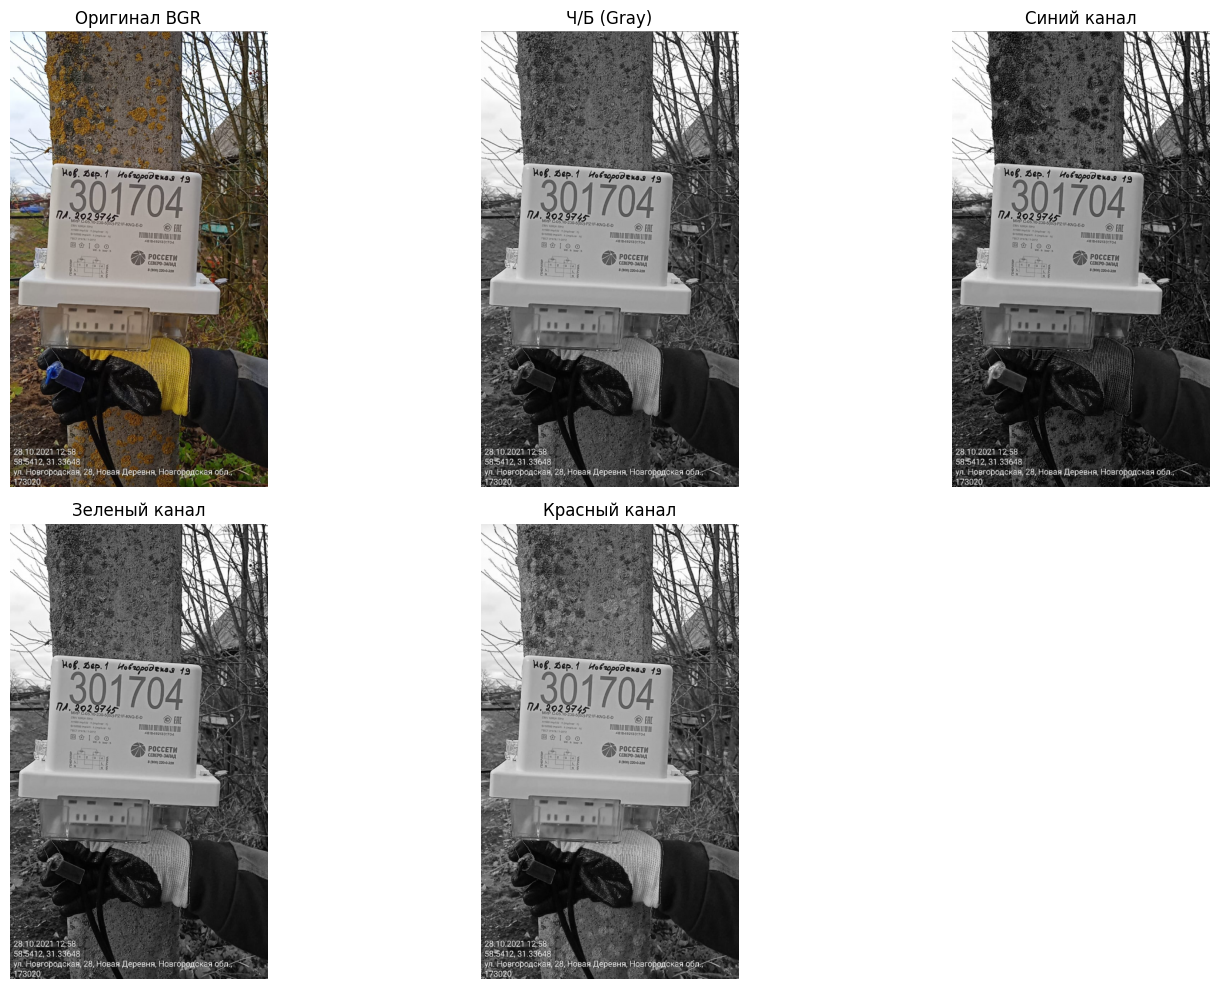

In [19]:
titles = ['Оригинал BGR', 'Ч/Б (Gray)', 'Синий канал', 'Зеленый канал', 'Красный канал']
images = [img, gray, blue_channel, green_channel, red_channel]

plt.figure(figsize=(15, 10))
for i in range(5):
    plt.subplot(2, 3, i+1)
    if i == 0:
        # matplotlib ожидает RGB, поэтому конвертируем оригинал для отображения
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    else:
        # Остальные каналы показываем как Ч/Б (яркость канала)
        plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## 2. Вывод по предобработке изображений:

Перевод в Ч/Б (Grayscale): Помогает в большинстве случаев предобработки (особенно для OCR). Он убирает лишнюю цветовую информацию (фон, цвет корпуса), оставляя только контраст между цифрами и подложкой. Это снижает вычислительную нагрузку на нейросеть и убирает шумы, связанные с цветными пятнами или бликами определенного цвета.

Разложение на RGB (BGR) каналы: Требуется в специфических ситуациях. Например, если цифры на счетчике красные, а фон зеленый, то в Ч/Б они могут слиться (иметь одинаковую яркость). В этом случае, выделив только Красный канал, мы получим максимальный контраст цифр. Также это помогает, если изображение повреждено бликом определенного цвета (например, синим от лампы) - можно просто отбросить синий канал при анализе.

## 3. Применяем нейронку

Импорт нейронки и других библиотек

In [ ]:
import easyocr
import pandas as pd
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/kinet/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Инициализация распознавателя (выбираем английский язык для цифр)

In [21]:
reader = easyocr.Reader(['en'], gpu=False)

Using CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Загружаем и предобрабатываем изображение (лучше подавать Ч/Б)

In [97]:
file_path = 'images/371414.png'
img = cv2.imread(file_path)

Обрабатываем изображение и применяем нейронку

Код: 301729  confidence=0.74


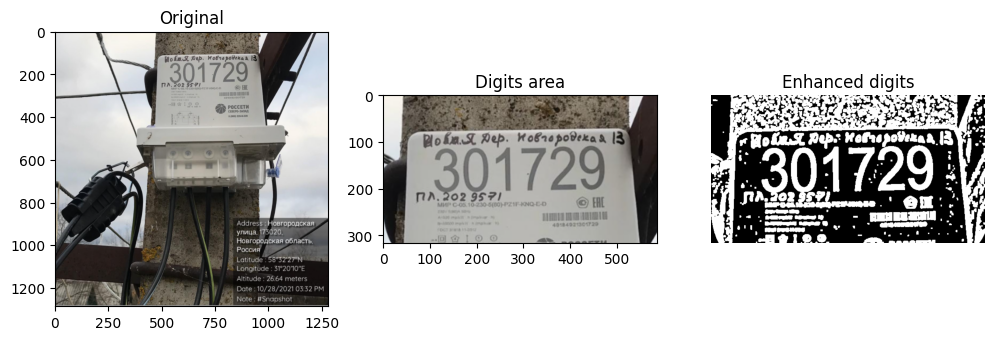

In [98]:
# увеличим изображение (OCR лучше работает)
img_big = cv2.resize(img, None, fx=1.5, fy=1.5)

# OCR поиск текста

results = reader.readtext(img_big)

best_box = None
best_code = None
best_area = 0
best_conf = 0

for bbox, text, prob in results:

    clean = "".join(filter(str.isdigit, text))

    if len(clean) == 6:  # номер счетчика

        pts = np.array(bbox).astype(int)

        x = pts[:,0].min()
        y = pts[:,1].min()
        w = pts[:,0].max() - x
        h = pts[:,1].max() - y

        area = w*h

        if area > best_area:
            best_area = area
            best_box = (x,y,w,h)
            best_code = clean
            best_conf = prob

if best_box is None:
    print("цифры не найдены")
    exit()

x,y,w,h = best_box

# добавим отступ вокруг цифр
pad = int(h*0.8)

x1 = max(0, x-pad)
y1 = max(0, y-pad)
x2 = min(img_big.shape[1], x+w+pad)
y2 = min(img_big.shape[0], y+h+pad)

roi = img_big[y1:y2, x1:x2]

# Усиление цифр

gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit=3.0,tileGridSize=(8,8))
gray = clahe.apply(gray)

blur = cv2.GaussianBlur(gray,(3,3),0)

th = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    4
)

kernel = np.ones((3,3),np.uint8)
th = cv2.dilate(th,kernel,iterations=1)

# вывод

print(f"Код: {best_code}  confidence={best_conf:.2f}")

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img_big,cv2.COLOR_BGR2RGB))

plt.subplot(1,3,2)
plt.title("Digits area")
plt.imshow(cv2.cvtColor(roi,cv2.COLOR_BGR2RGB))

plt.subplot(1,3,3)
plt.title("Enhanced digits")
plt.imshow(th,cmap="gray")

plt.axis("off")
plt.show()